#🧠 Prediksi Depresi Mahasiswa — Student Depression Dataset
**Fast Track Bengkel Koding Data Science — Universitas Dian Nuswantoro**

## 1. Import Library & Load Data

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif

import joblib, os
print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


In [2]:
df_raw = pd.read_csv('Bengkod-Depresi.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (28008, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Informasi Dasar Dataset

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 non-null  object 
 11  Di

In [4]:
df_raw.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


### 2.2 Missing Values

Kolom dengan Missing Values:


,Missing Count,Missing (%)
Financial Stress,45,0.16
Family History of Mental Illness,42,0.15
Depression,42,0.15


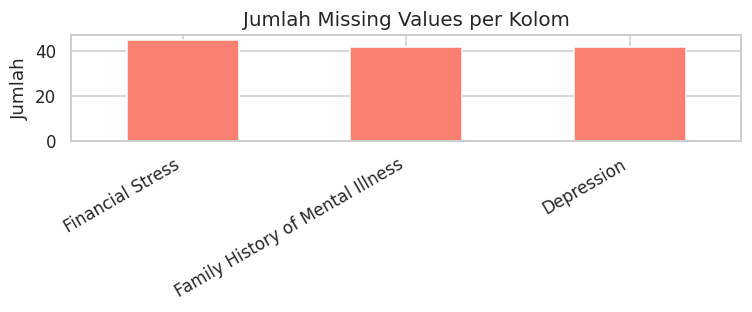

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Kolom dengan Missing Values:')
display(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Missing Count'].plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Jumlah Missing Values per Kolom', fontsize=13)
ax.set_ylabel('Jumlah')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 2.3 Distribusi Target Variable (Depression)

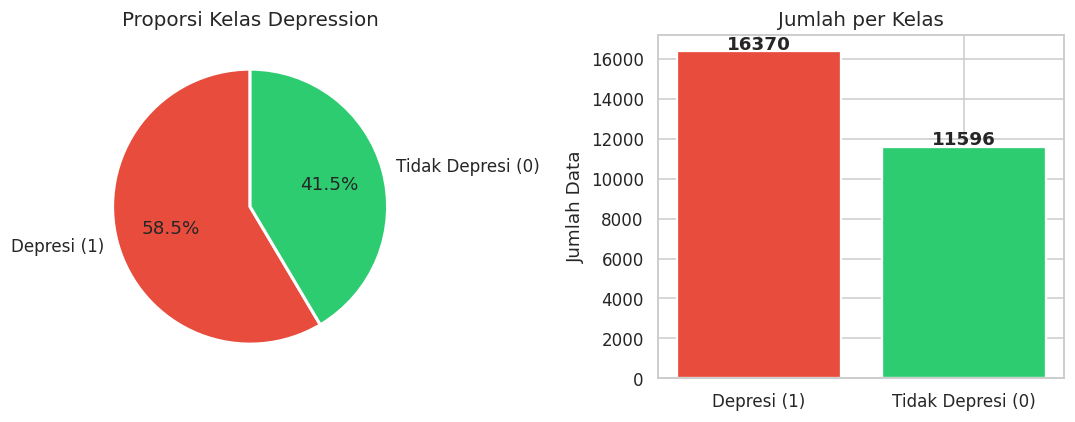

In [6]:
df_eda = df_raw.dropna(subset=['Depression']).copy()
target_counts = df_eda['Depression'].value_counts()
labels = ['Depresi (1)', 'Tidak Depresi (0)']
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie(target_counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title('Proporsi Kelas Depression', fontsize=13)
axes[1].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Jumlah per Kelas', fontsize=13)
axes[1].set_ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

### 2.4 Distribusi Fitur Numerik

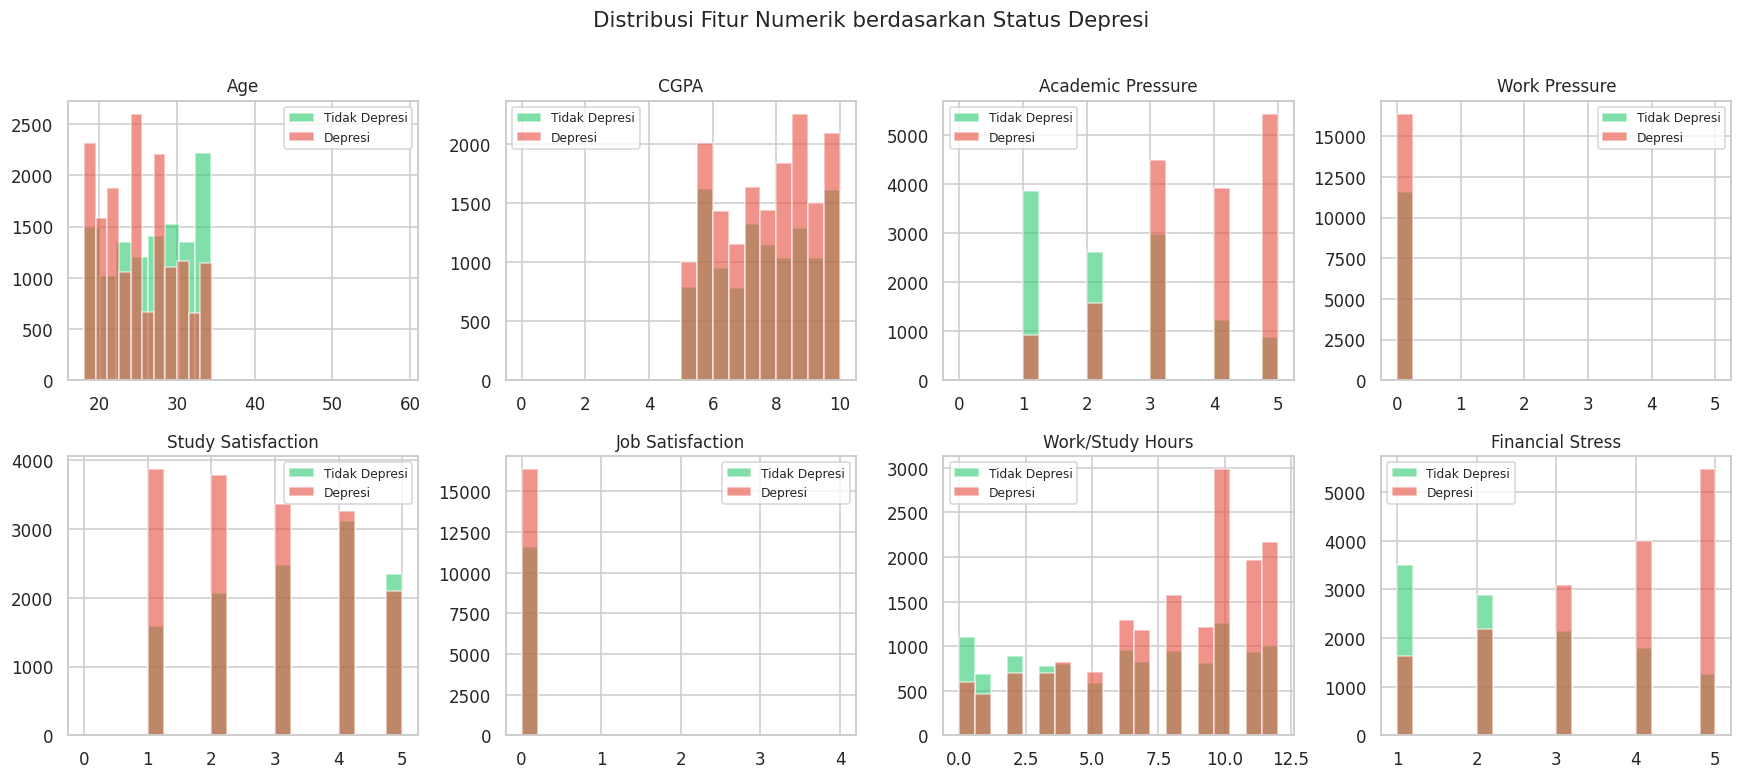

In [7]:
num_cols = ['Age', 'CGPA', 'Academic Pressure', 'Work Pressure',
            'Study Satisfaction', 'Job Satisfaction',
            'Work/Study Hours', 'Financial Stress']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    dep_0 = df_eda[df_eda['Depression'] == 0.0][col].dropna()
    dep_1 = df_eda[df_eda['Depression'] == 1.0][col].dropna()
    axes[i].hist(dep_0, bins=20, alpha=0.6, color='#2ecc71', label='Tidak Depresi')
    axes[i].hist(dep_1, bins=20, alpha=0.6, color='#e74c3c', label='Depresi')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
plt.suptitle('Distribusi Fitur Numerik berdasarkan Status Depresi', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Distribusi Fitur Kategorikal terhadap Target

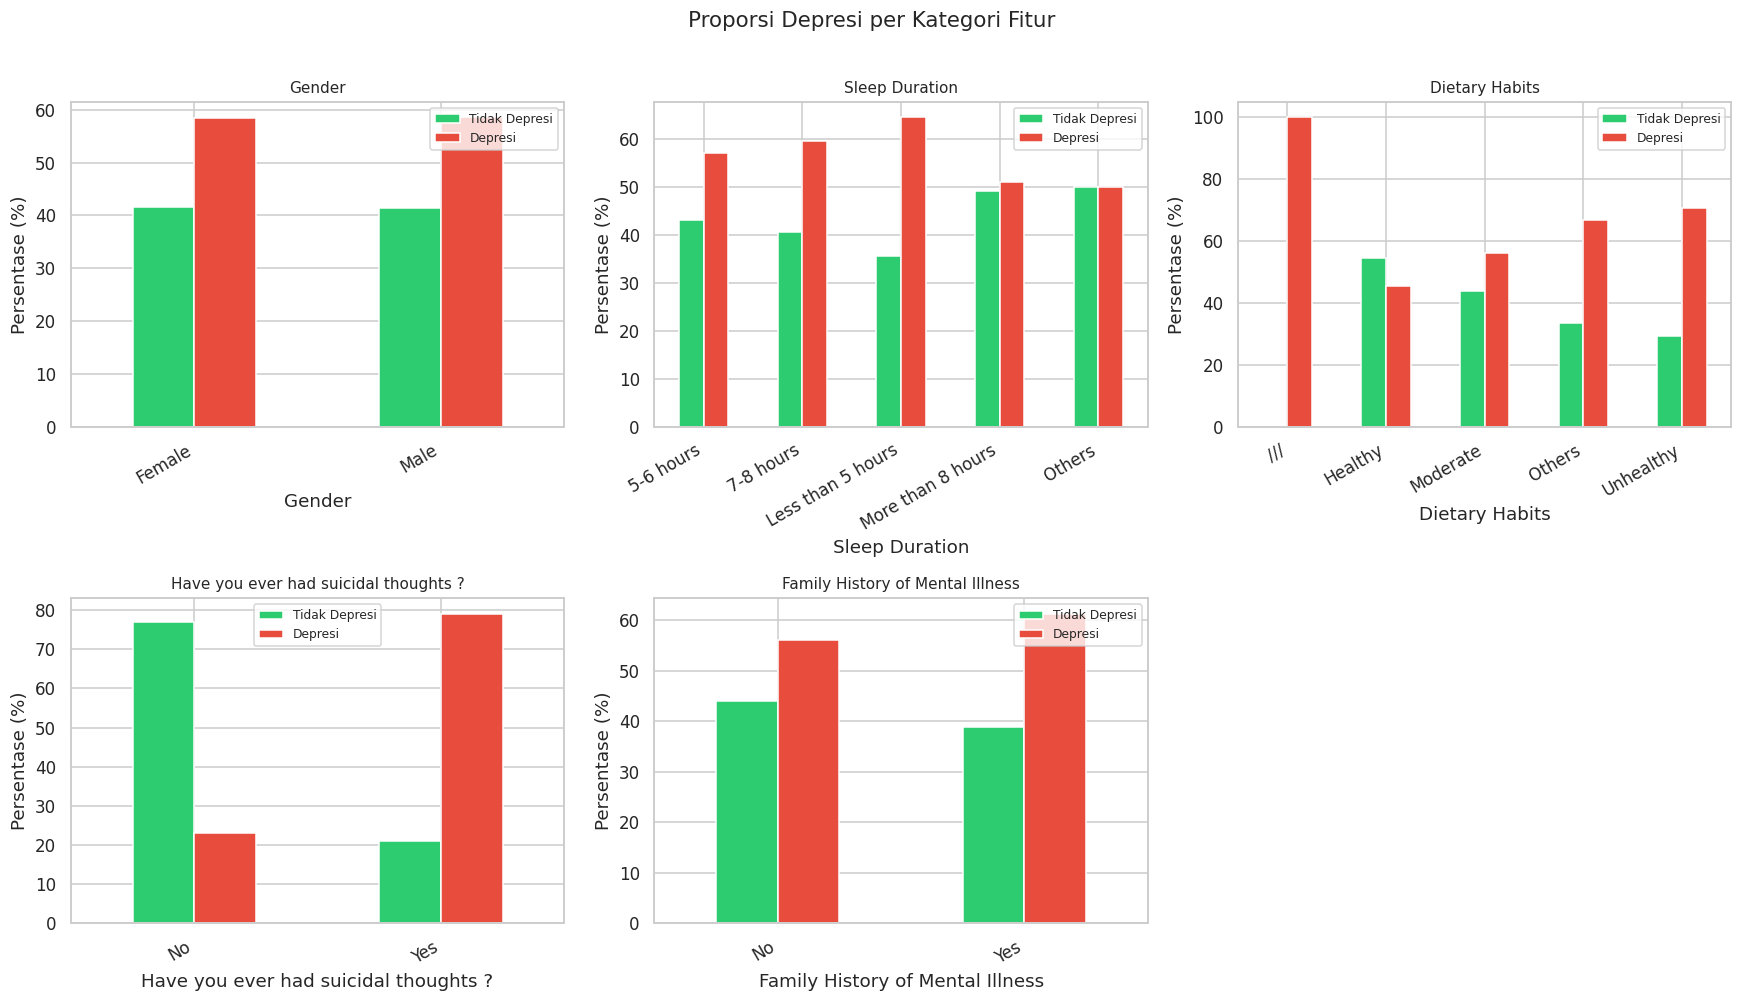

In [8]:
cat_cols_plot = ['Gender', 'Sleep Duration', 'Dietary Habits',
                 'Have you ever had suicidal thoughts ?',
                 'Family History of Mental Illness']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols_plot):
    ct = pd.crosstab(df_eda[col], df_eda['Depression'], normalize='index') * 100
    ct.columns = ['Tidak Depresi', 'Depresi']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Persentase (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].legend(fontsize=8)
axes[-1].set_visible(False)
plt.suptitle('Proporsi Depresi per Kategori Fitur', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.6 Heatmap Korelasi Fitur Numerik

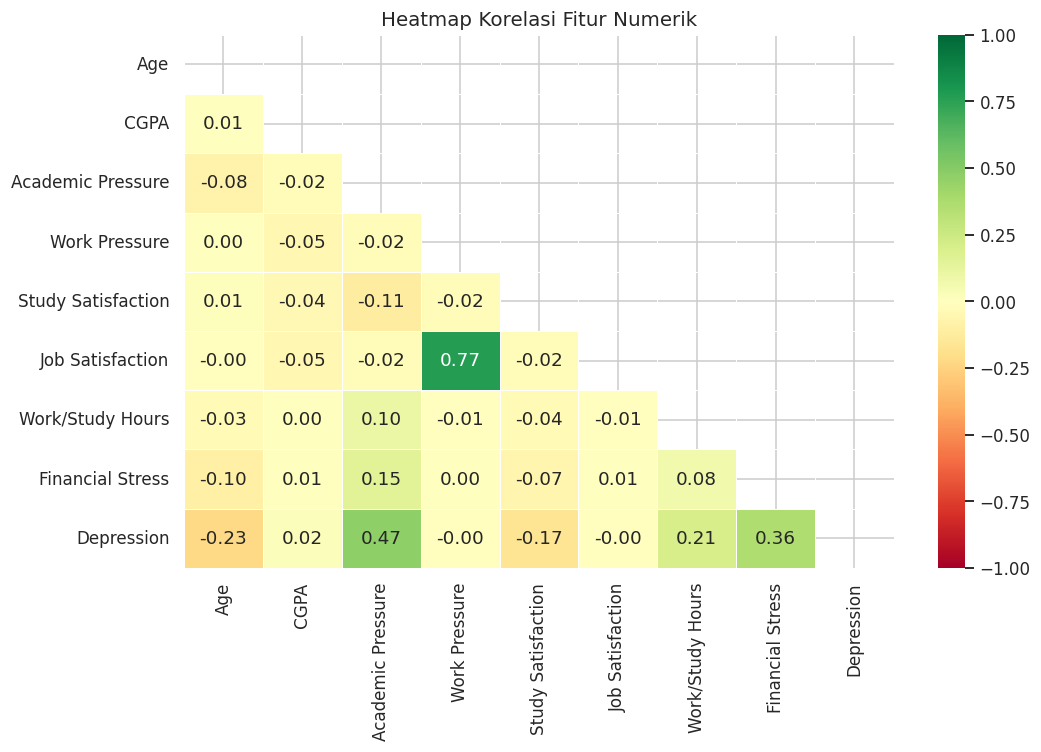

Korelasi terhadap Depression:
Academic Pressure     0.474832
Financial Stress      0.363925
Work/Study Hours      0.208630
CGPA                  0.022515
Work Pressure        -0.003344
Job Satisfaction     -0.003474
Study Satisfaction   -0.168613
Age                  -0.226397
Name: Depression, dtype: float64


In [9]:
corr_cols = num_cols + ['Depression']
corr_matrix = df_eda[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

print('Korelasi terhadap Depression:')
print(corr_matrix['Depression'].drop('Depression').sort_values(ascending=False))

### 2.7 Analisis Nilai Tidak Wajar (Anomali)

In [10]:
print('=== Kolom yang Di-drop (tidak informatif) ===')
print('\n• id       → hanya identifier unik, tidak relevan untuk prediksi')
print('• City     → 52 nilai unik, terlalu banyak noise, tidak representatif')
print('• Profession → 99.9% bernilai "Student", hampir tidak ada variansi')

print('\n=== Anomali Nilai ===')
print('\nDietary Habits:')
print(df_raw['Dietary Habits'].value_counts())
print('→ Nilai "///" tidak valid → akan diubah ke "Others"')

print('\nWork Pressure value counts:')
print(df_raw['Work Pressure'].value_counts())
print('→ 99.98% bernilai 0 (mayoritas mahasiswa tidak bekerja)')
print('→ Kolom TETAP DIPERTAHANKAN di form input sebagai informasi konteks,')
print('  namun nilainya terlalu rendah variansinya untuk menjadi fitur prediksi utama')

print('\nJob Satisfaction value counts:')
print(df_raw['Job Satisfaction'].value_counts())
print('→ 99.97% bernilai 0 (mayoritas mahasiswa tidak bekerja)')
print('→ Sama seperti Work Pressure, dipertahankan di form namun bukan fitur utama prediksi')

=== Kolom yang Di-drop (tidak informatif) ===

• id       → hanya identifier unik, tidak relevan untuk prediksi
• City     → 52 nilai unik, terlalu banyak noise, tidak representatif
• Profession → 99.9% bernilai "Student", hampir tidak ada variansi

=== Anomali Nilai ===

Dietary Habits:
Dietary Habits
Unhealthy    10354
Moderate      9959
Healthy       7682
Others          12
///              1
Name: count, dtype: int64
→ Nilai "///" tidak valid → akan diubah ke "Others"

Work Pressure value counts:
Work Pressure
0    28005
5        2
2        1
Name: count, dtype: int64
→ 99.98% bernilai 0 (mayoritas mahasiswa tidak bekerja)
→ Kolom TETAP DIPERTAHANKAN di form input sebagai informasi konteks,
  namun nilainya terlalu rendah variansinya untuk menjadi fitur prediksi utama

Job Satisfaction value counts:
Job Satisfaction
0    28000
2        3
4        2
1        2
3        1
Name: count, dtype: int64
→ 99.97% bernilai 0 (mayoritas mahasiswa tidak bekerja)
→ Sama seperti Work Pressure, d

---
## 📌 Insight Utama dari EDA

### Insight 1 — Pikiran Bunuh Diri adalah Prediktor Terkuat
Mahasiswa yang pernah memiliki pikiran untuk bunuh diri memiliki proporsi depresi yang jauh lebih tinggi. Variabel `Have you ever had suicidal thoughts?` merupakan sinyal paling kuat terhadap status depresi.

**Keputusan:** Kolom ini dipertahankan dan dikodekan secara biner (Ya=1, Tidak=0).

---
### Insight 2 — Durasi Tidur Berkorelasi dengan Depresi
Mahasiswa yang tidur kurang dari 5 jam menunjukkan proporsi depresi lebih tinggi, sementara yang tidur 7–8 jam cenderung lebih sehat secara mental.

**Keputusan:** Kolom `Sleep Duration` di-encode ordinal (skor 1–4) agar model menangkap relasi urutannya.

---
### Insight 3 — Financial Stress & Academic Pressure Berkorelasi Positif dengan Depresi
`Financial Stress` dan `Academic Pressure` memiliki korelasi positif lebih tinggi terhadap `Depression` dibanding fitur numerik lainnya.

**Keputusan:** Kedua fitur dipertahankan. Kolom `Work Pressure` dan `Job Satisfaction` tetap disertakan di form input (sebagai representasi 18 kolom dataset) namun nilainya sangat rendah variansinya karena mayoritas responden adalah mahasiswa yang tidak bekerja.

---

## 3. Direct Modeling (Tanpa Preprocessing)

> Membangun model langsung dari data mentah dengan encoding minimal sebagai **baseline/kontrol** untuk mengukur efektivitas preprocessing.

### Alasan Pemilihan Model

| Model | Alasan Pemilihan |
|---|---|
| **Logistic Regression** | Baseline klasik untuk klasifikasi biner; cepat dan interpretatif |
| **Decision Tree** | Dapat menangani fitur campuran dan mudah diinterpretasi |
| **K-Nearest Neighbors** | Tidak membuat asumsi distribusi; berguna untuk pola lokal |
| **Naive Bayes** | Efisien pada dataset besar; baseline probabilistik yang solid |
| **Random Forest** | Ensemble bagging yang robust terhadap overfitting |
| **Gradient Boosting** | Ensemble boosting iteratif yang umumnya memberikan performa tinggi |
| **XGBoost** | Optimasi Gradient Boosting dengan regularisasi; sangat kompetitif pada data tabular |

In [11]:
# Persiapan data untuk Direct Modeling
df_direct = df_raw.dropna(subset=['Depression']).copy()

# Drop hanya kolom identifier
df_direct.drop(columns=['id', 'City', 'Profession'], inplace=True)

# Encode kategorikal dengan LabelEncoder
cat_cols_direct = df_direct.select_dtypes(include='object').columns.tolist()
le_direct = {}
for col in cat_cols_direct:
    le = LabelEncoder()
    df_direct[col] = df_direct[col].fillna('Unknown')
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))
    le_direct[col] = le

# Isi missing value numerik dengan median
for col in df_direct.select_dtypes(include='number').columns:
    df_direct[col] = df_direct[col].fillna(df_direct[col].median())

X_direct = df_direct.drop(columns=['Depression'])
y_direct = df_direct['Depression'].astype(int)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct)

print(f'Fitur yang digunakan ({len(X_direct.columns)}): {X_direct.columns.tolist()}')
print(f'Train: {X_train_d.shape}, Test: {X_test_d.shape}')

Fitur yang digunakan (14): ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Train: (22372, 14), Test: (5594, 14)


In [12]:
models_direct = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes':         GaussianNB(),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results_direct = []
for name, model in models_direct.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    acc = accuracy_score(y_test_d, y_pred)
    f1  = f1_score(y_test_d, y_pred)
    roc = roc_auc_score(y_test_d, model.predict_proba(X_test_d)[:,1]
                        if hasattr(model, 'predict_proba') else y_pred)
    results_direct.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc})
    print(f'{name:25s} → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc:.4f}')

df_results_direct = pd.DataFrame(results_direct).sort_values('Accuracy', ascending=False)
print('\n✅ Direct Modeling selesai!')

Logistic Regression       → Acc: 0.8447 | F1: 0.8696 | AUC: 0.9185
Decision Tree             → Acc: 0.7699 | F1: 0.8015 | AUC: 0.7651
K-Nearest Neighbors       → Acc: 0.7867 | F1: 0.8244 | AUC: 0.8425
Naive Bayes               → Acc: 0.8384 | F1: 0.8675 | AUC: 0.9164
Random Forest             → Acc: 0.8373 | F1: 0.8633 | AUC: 0.9143
Gradient Boosting         → Acc: 0.8477 | F1: 0.8722 | AUC: 0.9204
XGBoost                   → Acc: 0.8359 | F1: 0.8618 | AUC: 0.9137

✅ Direct Modeling selesai!


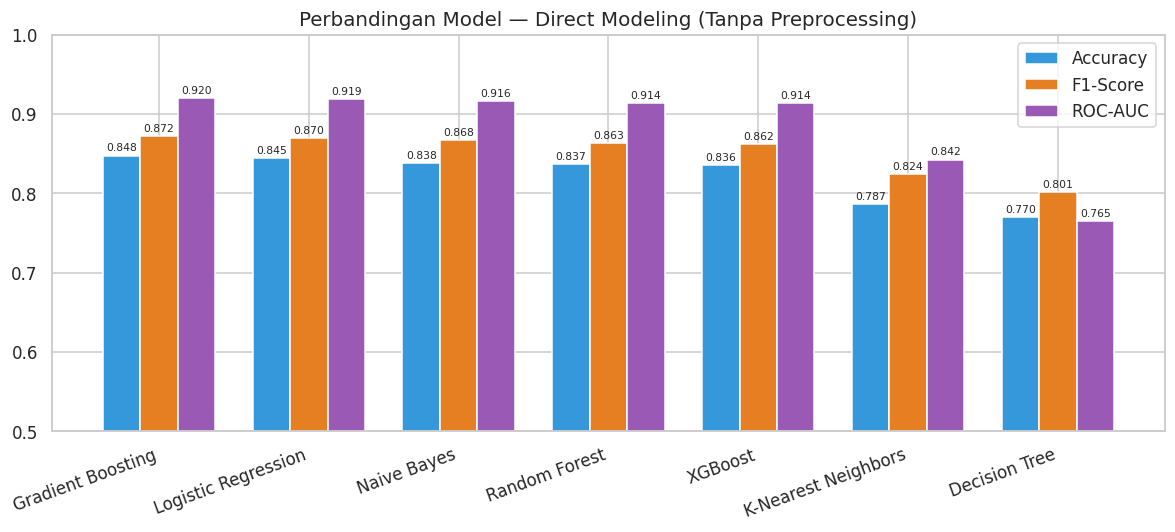

,Accuracy,F1-Score,ROC-AUC
Model,,,
Gradient Boosting,0.8477,0.8722,0.9204
Logistic Regression,0.8447,0.8696,0.9185
Naive Bayes,0.8384,0.8675,0.9164
Random Forest,0.8373,0.8633,0.9143
XGBoost,0.8359,0.8618,0.9137
K-Nearest Neighbors,0.7867,0.8244,0.8425
Decision Tree,0.7699,0.8015,0.7651


In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_results_direct))
w = 0.25
ax.bar(x - w, df_results_direct['Accuracy'], w, label='Accuracy', color='#3498db')
ax.bar(x,     df_results_direct['F1-Score'], w, label='F1-Score', color='#e67e22')
ax.bar(x + w, df_results_direct['ROC-AUC'], w, label='ROC-AUC',  color='#9b59b6')
ax.set_xticks(x)
ax.set_xticklabels(df_results_direct['Model'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_title('Perbandingan Model — Direct Modeling (Tanpa Preprocessing)', fontsize=13)
ax.legend()
for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=7)
plt.tight_layout()
plt.show()
display(df_results_direct.set_index('Model').style.highlight_max(color='lightgreen').format('{:.4f}'))

## 4. Modeling dengan Preprocessing

> Menggunakan **14 fitur** (setelah drop `id`, `City`, `Profession` yang tidak informatif) dengan preprocessing lengkap.

### 4.1 Preprocessing Pipeline

In [14]:
df_pp = df_raw.copy()

# 1. Drop baris dengan target NaN
df_pp = df_pp.dropna(subset=['Depression'])

# 2. Drop kolom tidak informatif
# - id     : hanya identifier
# - City   : 52 nilai unik, terlalu noisy
# - Profession : 99.9% bernilai 'Student'
drop_cols = ['id', 'City', 'Profession']
df_pp.drop(columns=drop_cols, inplace=True)

print(f'Fitur setelah drop kolom tidak informatif ({len(df_pp.columns)-1} fitur):')
print([c for c in df_pp.columns if c != 'Depression'])

Fitur setelah drop kolom tidak informatif (14 fitur):
['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']


In [15]:
# 3. Perbaiki nilai anomali
df_pp['Dietary Habits'] = df_pp['Dietary Habits'].replace('///', 'Others')
print('Dietary Habits setelah perbaikan:')
print(df_pp['Dietary Habits'].value_counts())

Dietary Habits setelah perbaikan:
Dietary Habits
Unhealthy    10334
Moderate      9950
Healthy       7669
Others          13
Name: count, dtype: int64


In [16]:
# 4. Imputasi missing value
df_pp['Financial Stress'] = df_pp['Financial Stress'].fillna(df_pp['Financial Stress'].median())
df_pp['Family History of Mental Illness'] = df_pp['Family History of Mental Illness'].fillna(
    df_pp['Family History of Mental Illness'].mode()[0])

print('Missing values setelah imputasi:')
print(df_pp.isnull().sum()[df_pp.isnull().sum() > 0])
print('✅ Tidak ada missing value tersisa')

Missing values setelah imputasi:
Series([], dtype: int64)
✅ Tidak ada missing value tersisa


In [17]:
# 5. Encoding

# Ordinal encoding — Sleep Duration
sleep_order = {
    'Less than 5 hours': 1, '5-6 hours': 2,
    '7-8 hours': 3, 'More than 8 hours': 4, 'Others': 2
}
df_pp['Sleep Duration'] = df_pp['Sleep Duration'].map(sleep_order)

# Ordinal encoding — Dietary Habits
diet_order = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3, 'Others': 2}
df_pp['Dietary Habits'] = df_pp['Dietary Habits'].map(diet_order)

# Binary encoding
df_pp['Gender'] = df_pp['Gender'].map({'Male': 0, 'Female': 1})
df_pp['Have you ever had suicidal thoughts ?'] = df_pp['Have you ever had suicidal thoughts ?'].map({'No': 0, 'Yes': 1})
df_pp['Family History of Mental Illness'] = df_pp['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})

# Label encoding — Degree
le_degree = LabelEncoder()
df_pp['Degree'] = le_degree.fit_transform(df_pp['Degree'].astype(str))

print('Shape setelah preprocessing:', df_pp.shape)
print('\nTipe data:')
print(df_pp.dtypes)
df_pp.head()

Shape setelah preprocessing: (27966, 15)

Tipe data:
Gender                                     int64
Age                                        int64
Academic Pressure                          int64
Work Pressure                              int64
CGPA                                     float64
Study Satisfaction                         int64
Job Satisfaction                           int64
Sleep Duration                             int64
Dietary Habits                             int64
Degree                                     int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                           int64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                               float64
dtype: object


,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,33,5,0,8.97,2,0,2,3,3,1,3,1.0,0,1.0
1,1,24,2,0,5.90,5,0,2,2,10,0,3,2.0,1,0.0
2,0,31,3,0,7.03,5,0,1,3,5,0,9,1.0,1,0.0
3,1,28,3,0,5.59,2,0,3,2,7,1,4,5.0,1,1.0
4,1,25,4,0,8.13,3,0,2,2,17,1,1,1.0,0,0.0


In [18]:
# 6. Split fitur dan target
X = df_pp.drop(columns=['Depression'])
y = df_pp['Depression'].astype(int)

# 7. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print(f'Jumlah fitur setelah preprocessing: {X.shape[1]}')
print(f'Daftar fitur: {X.columns.tolist()}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('✅ Preprocessing selesai!')

Jumlah fitur setelah preprocessing: 14
Daftar fitur: ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Train: (22372, 14), Test: (5594, 14)
✅ Preprocessing selesai!


### 4.2 Training & Evaluasi Model (dengan Preprocessing)

In [19]:
models_pp = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes':         GaussianNB(),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results_pp = []
trained_models = {}
for name, model in models_pp.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1]
                        if hasattr(model, 'predict_proba') else y_pred)
    results_pp.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc})
    trained_models[name] = model
    print(f'{name:25s} → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc:.4f}')

df_results_pp = pd.DataFrame(results_pp).sort_values('Accuracy', ascending=False)
print('\n✅ Modeling dengan Preprocessing selesai!')

Logistic Regression       → Acc: 0.8466 | F1: 0.8708 | AUC: 0.9197
Decision Tree             → Acc: 0.7574 | F1: 0.7924 | AUC: 0.7505
K-Nearest Neighbors       → Acc: 0.8227 | F1: 0.8516 | AUC: 0.8783
Naive Bayes               → Acc: 0.8398 | F1: 0.8686 | AUC: 0.9170
Random Forest             → Acc: 0.8379 | F1: 0.8635 | AUC: 0.9149
Gradient Boosting         → Acc: 0.8468 | F1: 0.8713 | AUC: 0.9208
XGBoost                   → Acc: 0.8357 | F1: 0.8615 | AUC: 0.9119

✅ Modeling dengan Preprocessing selesai!


In [20]:
# Perbandingan Direct vs Preprocessing
comp = df_results_direct.set_index('Model')[['Accuracy']].rename(columns={'Accuracy':'Direct'})
comp['Preprocessed'] = df_results_pp.set_index('Model')['Accuracy']
comp['Delta (+/-)'] = (comp['Preprocessed'] - comp['Direct']).round(4)
print('Perbandingan Akurasi Direct vs Preprocessing:')
display(comp.style.applymap(
    lambda x: 'color: green' if isinstance(x, float) and x > 0
    else ('color: red' if isinstance(x, float) and x < 0 else ''),
    subset=['Delta (+/-)']))

Perbandingan Akurasi Direct vs Preprocessing:


,Direct,Preprocessed,Delta (+/-)
Model,,,
Gradient Boosting,0.847694,0.846800,-0.000900
Logistic Regression,0.844655,0.846621,0.002000
Naive Bayes,0.838398,0.839828,0.001400
Random Forest,0.837326,0.837862,0.000500
XGBoost,0.835896,0.835717,-0.000200
K-Nearest Neighbors,0.786736,0.822667,0.035900
Decision Tree,0.769932,0.757419,-0.012500


---
<a id='5'></a>
## 5. Feature Selection

> Memilih fitur paling relevan dari **14 fitur** menggunakan kombinasi 3 metode:
> 1. **Korelasi Pearson** terhadap target
> 2. **SelectKBest (ANOVA F-test)**
> 3. **Feature Importance dari Random Forest**
>
> Fitur yang konsisten masuk ranking tinggi di minimal 2 dari 3 metode akan dipilih.
> Hasil seleksi digunakan untuk melatih model agar lebih efisien dan akurat.

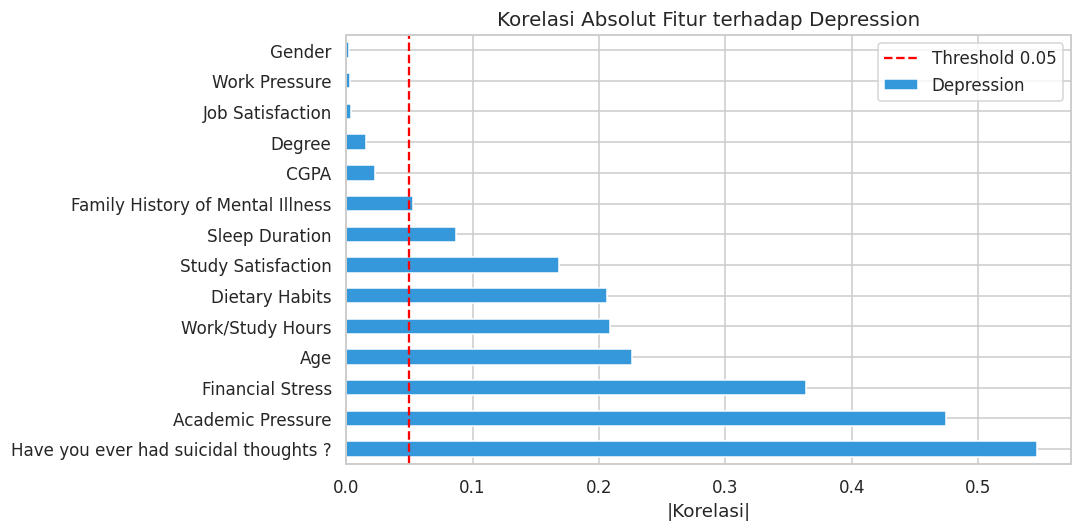

Have you ever had suicidal thoughts ?    0.546565
Academic Pressure                        0.474874
Financial Stress                         0.363907
Age                                      0.226308
Work/Study Hours                         0.208565
Dietary Habits                           0.206268
Study Satisfaction                       0.168574
Sleep Duration                           0.086826
Family History of Mental Illness         0.053141
CGPA                                     0.022458
Degree                                   0.015578
Job Satisfaction                         0.003473
Work Pressure                            0.003344
Gender                                   0.001974
Name: Depression, dtype: float64


In [21]:
# Metode 1: Korelasi Pearson
corr_target = df_pp.corr()['Depression'].drop('Depression').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_target.plot(kind='barh', ax=ax, color='#3498db')
ax.axvline(0.05, color='red', linestyle='--', label='Threshold 0.05')
ax.set_title('Korelasi Absolut Fitur terhadap Depression', fontsize=13)
ax.set_xlabel('|Korelasi|')
ax.legend()
plt.tight_layout()
plt.show()
print(corr_target)

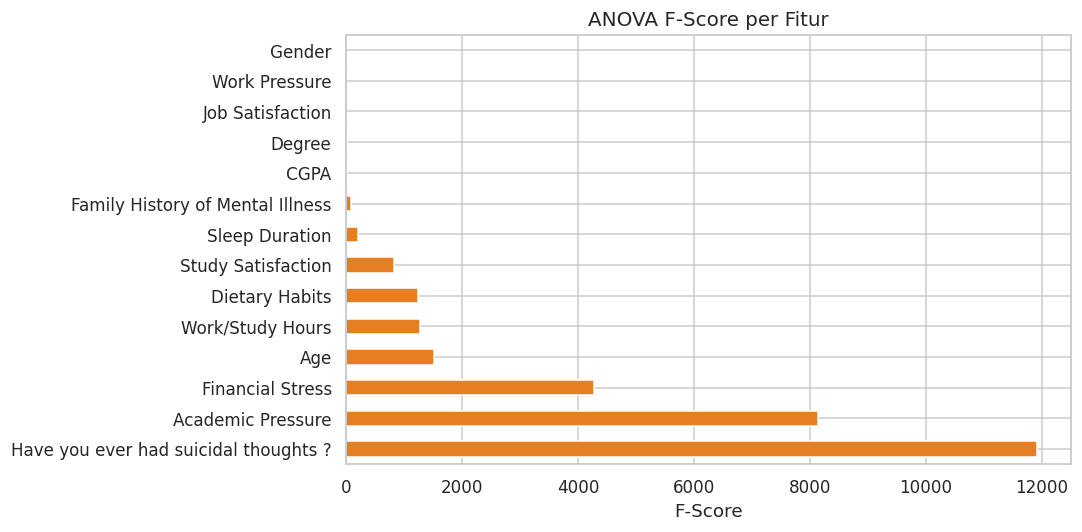

Have you ever had suicidal thoughts ?    11912.391622
Academic Pressure                         8142.121381
Financial Stress                          4268.497796
Age                                       1509.494735
Work/Study Hours                          1271.742145
Dietary Habits                            1242.640533
Study Satisfaction                         817.902860
Sleep Duration                             212.413939
Family History of Mental Illness            79.192928
CGPA                                        14.111073
Degree                                       6.787915
Job Satisfaction                             0.337282
Work Pressure                                0.312645
Gender                                       0.108945
dtype: float64


In [22]:
# Metode 2: SelectKBest (ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled_df, y)
f_scores = pd.Series(selector.scores_, index=X_scaled_df.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
f_scores.plot(kind='barh', ax=ax, color='#e67e22')
ax.set_title('ANOVA F-Score per Fitur', fontsize=13)
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.show()
print(f_scores)

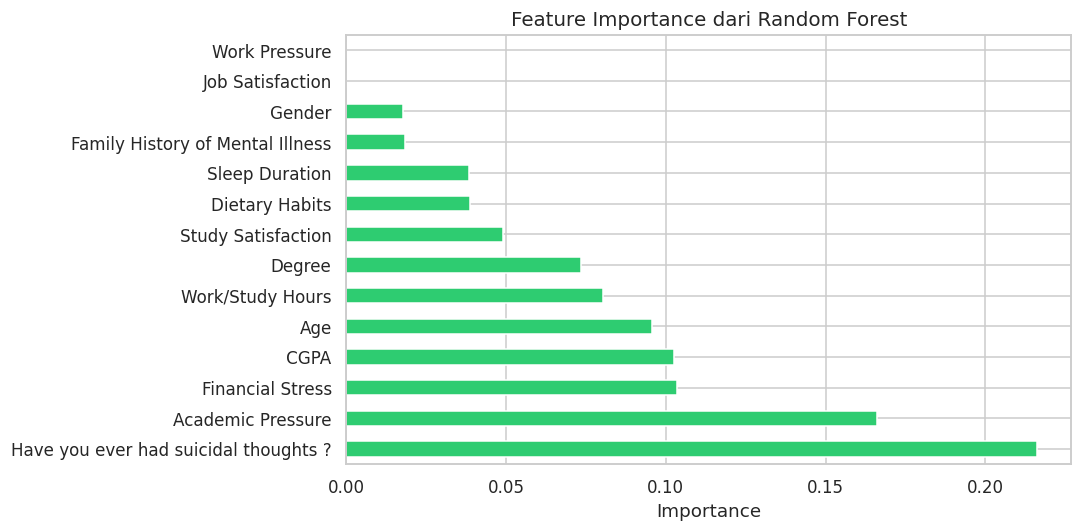

Have you ever had suicidal thoughts ?    0.216111
Academic Pressure                        0.165972
Financial Stress                         0.103375
CGPA                                     0.102445
Age                                      0.095656
Work/Study Hours                         0.080235
Degree                                   0.073631
Study Satisfaction                       0.049189
Dietary Habits                           0.038739
Sleep Duration                           0.038349
Family History of Mental Illness         0.018310
Gender                                   0.017876
Job Satisfaction                         0.000093
Work Pressure                            0.000018
dtype: float64


In [23]:
# Metode 3: Feature Importance (Random Forest)
rf_fi = trained_models['Random Forest']
importances = pd.Series(rf_fi.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('Feature Importance dari Random Forest', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances)

In [24]:
# Seleksi Final — gabungkan 3 metode
top_corr   = set(corr_target[corr_target >= 0.05].index.tolist())
top_ftest  = set(f_scores.head(10).index.tolist())
top_rf_imp = set(importances.head(10).index.tolist())

selected_features = list(
    (top_corr & top_ftest) | (top_corr & top_rf_imp) | (top_ftest & top_rf_imp)
)

print(f'\n✅ Fitur terpilih ({len(selected_features)}): {selected_features}')
print('\nCatatan: Fitur dipilih berdasarkan konsistensi ranking di minimal 2 dari 3 metode seleksi.')
print('Work Pressure & Job Satisfaction tidak terpilih karena variansinya sangat rendah')
print('(99%+ bernilai 0 karena mayoritas responden adalah mahasiswa yang tidak bekerja).')
print('Namun kedua kolom ini tetap tersedia di form input aplikasi sebagai representasi dataset asli.')

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]


✅ Fitur terpilih (10): ['Have you ever had suicidal thoughts ?', 'Sleep Duration', 'Age', 'Financial Stress', 'Work/Study Hours', 'Dietary Habits', 'Study Satisfaction', 'Family History of Mental Illness', 'CGPA', 'Academic Pressure']

Catatan: Fitur dipilih berdasarkan konsistensi ranking di minimal 2 dari 3 metode seleksi.
Work Pressure & Job Satisfaction tidak terpilih karena variansinya sangat rendah
(99%+ bernilai 0 karena mayoritas responden adalah mahasiswa yang tidak bekerja).
Namun kedua kolom ini tetap tersedia di form input aplikasi sebagai representasi dataset asli.


In [25]:
# Training ulang dengan fitur terpilih
results_fs = []
models_fs  = {}
for name, ModelClass in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree',       DecisionTreeClassifier(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes',         GaussianNB()),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('XGBoost',             XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss', verbosity=0)),
]:
    ModelClass.fit(X_train_sel, y_train)
    y_pred = ModelClass.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, ModelClass.predict_proba(X_test_sel)[:,1]
                        if hasattr(ModelClass, 'predict_proba') else y_pred)
    results_fs.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc})
    models_fs[name] = ModelClass
    print(f'{name:25s} → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc:.4f}')

df_results_fs = pd.DataFrame(results_fs).sort_values('Accuracy', ascending=False)
display(df_results_fs.set_index('Model').style.highlight_max(color='lightgreen').format('{:.4f}'))

Logistic Regression       → Acc: 0.8466 | F1: 0.8708 | AUC: 0.9197
Decision Tree             → Acc: 0.7687 | F1: 0.8028 | AUC: 0.7613
K-Nearest Neighbors       → Acc: 0.8232 | F1: 0.8525 | AUC: 0.8807
Naive Bayes               → Acc: 0.8414 | F1: 0.8645 | AUC: 0.9174
Random Forest             → Acc: 0.8363 | F1: 0.8622 | AUC: 0.9108
Gradient Boosting         → Acc: 0.8491 | F1: 0.8733 | AUC: 0.9208
XGBoost                   → Acc: 0.8388 | F1: 0.8646 | AUC: 0.9125


,Accuracy,F1-Score,ROC-AUC
Model,,,
Gradient Boosting,0.8491,0.8733,0.9208
Logistic Regression,0.8466,0.8708,0.9197
Naive Bayes,0.8414,0.8645,0.9174
XGBoost,0.8388,0.8646,0.9125
Random Forest,0.8363,0.8622,0.9108
K-Nearest Neighbors,0.8232,0.8525,0.8807
Decision Tree,0.7687,0.8028,0.7613


## 6. Hyperparameter Tuning

> Melakukan optimasi pada model-model terbaik menggunakan **RandomizedSearchCV** (efisien untuk dataset besar) dan **GridSearchCV** untuk pencarian lebih presisi pada ruang parameter yang lebih kecil.

In [26]:
print('=== Hyperparameter Tuning: Random Forest ===')
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}
rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, n_iter=20, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
rf_tuned.fit(X_train_sel, y_train)
print(f'Best params RF : {rf_tuned.best_params_}')
print(f'Best CV score  : {rf_tuned.best_score_:.4f}')

=== Hyperparameter Tuning: Random Forest ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params RF : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV score  : 0.8437


In [27]:
print('=== Hyperparameter Tuning: XGBoost ===')
xgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_tuned = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid, n_iter=20, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_tuned.fit(X_train_sel, y_train)
print(f'Best params XGB: {xgb_tuned.best_params_}')
print(f'Best CV score  : {xgb_tuned.best_score_:.4f}')

=== Hyperparameter Tuning: XGBoost ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params XGB: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV score  : 0.8476


In [28]:
print('=== Hyperparameter Tuning: Gradient Boosting ===')
gb_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0]
}
gb_tuned = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid, n_iter=15, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
gb_tuned.fit(X_train_sel, y_train)
print(f'Best params GB : {gb_tuned.best_params_}')
print(f'Best CV score  : {gb_tuned.best_score_:.4f}')

=== Hyperparameter Tuning: Gradient Boosting ===
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params GB : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV score  : 0.8470


In [29]:
# Evaluasi semua model yang di-tuning
tuned_models = {
    'RF (Tuned)':  rf_tuned.best_estimator_,
    'XGB (Tuned)': xgb_tuned.best_estimator_,
    'GB (Tuned)':  gb_tuned.best_estimator_,
}

results_tuned = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test_sel)[:,1])
    results_tuned.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc})
    print(f'{name:15s} → Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {roc:.4f}')

df_tuned = pd.DataFrame(results_tuned).sort_values('Accuracy', ascending=False)
display(df_tuned.set_index('Model').style.highlight_max(color='lightgreen').format('{:.4f}'))

RF (Tuned)      → Acc: 0.8429 | F1: 0.8685 | AUC: 0.9178
XGB (Tuned)     → Acc: 0.8470 | F1: 0.8715 | AUC: 0.9211
GB (Tuned)      → Acc: 0.8470 | F1: 0.8717 | AUC: 0.9211


,Accuracy,F1-Score,ROC-AUC
Model,,,
XGB (Tuned),0.8470,0.8715,0.9211
GB (Tuned),0.8470,0.8717,0.9211
RF (Tuned),0.8429,0.8685,0.9178


In [30]:
# Rekapitulasi semua tahapan
all_results = pd.concat([
    df_results_direct.assign(Tahap='1. Direct Modeling'),
    df_results_pp.assign(Tahap='2. Preprocessing'),
    df_results_fs.assign(Tahap='3. Feature Selection'),
    df_tuned.assign(Tahap='4. Tuning')
], ignore_index=True)

print('=== REKAPITULASI SEMUA TAHAPAN ===')
display(all_results.sort_values('Accuracy', ascending=False).head(15)
        .set_index(['Tahap','Model'])
        .style.highlight_max(color='lightgreen', subset=['Accuracy','F1-Score','ROC-AUC'])
        .format('{:.4f}'))

=== REKAPITULASI SEMUA TAHAPAN ===


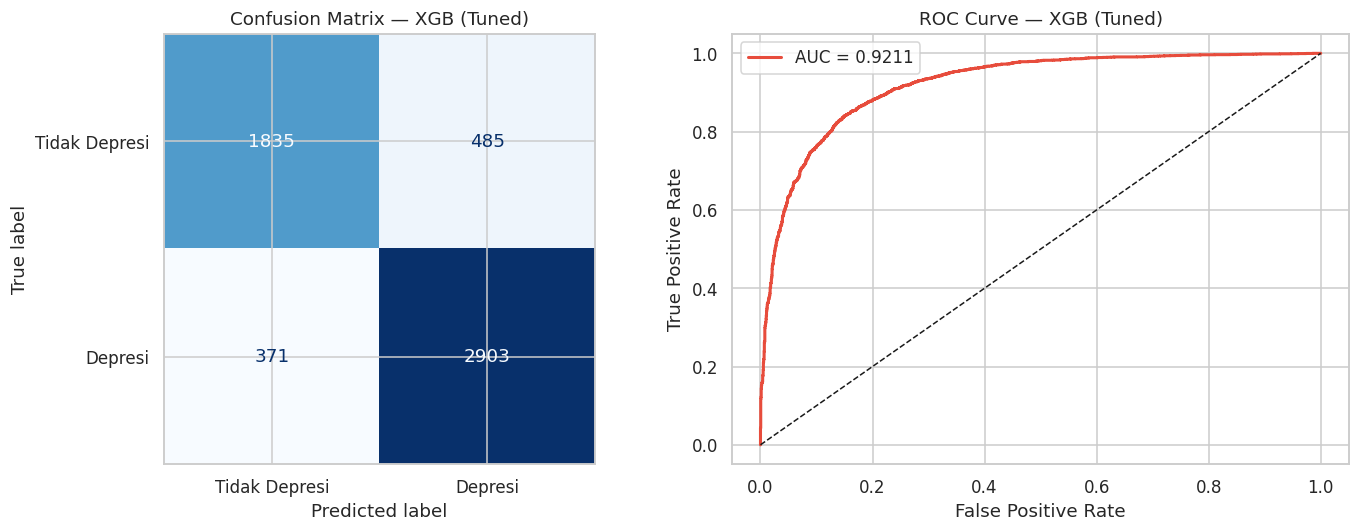


📋 Classification Report — XGB (Tuned):
               precision    recall  f1-score   support

Tidak Depresi       0.83      0.79      0.81      2320
      Depresi       0.86      0.89      0.87      3274

     accuracy                           0.85      5594
    macro avg       0.84      0.84      0.84      5594
 weighted avg       0.85      0.85      0.85      5594



In [31]:
# Confusion Matrix & ROC Curve model terbaik
best_name  = df_tuned.iloc[0]['Model']
best_model = tuned_models[best_name]
y_pred_best = best_model.predict(X_test_sel)
y_prob_best = best_model.predict_proba(X_test_sel)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Depresi','Depresi'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_val = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {best_name}', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n📋 Classification Report — {best_name}:')
print(classification_report(y_test, y_pred_best, target_names=['Tidak Depresi','Depresi']))

## 7. Simpan Model Terbaik untuk Deployment

In [33]:
os.makedirs('model', exist_ok=True)

# Simpan model terbaik
joblib.dump(best_model, 'model/best_model.pkl')

# Simpan scaler (dilatih pada 13 fitur)
joblib.dump(scaler, 'model/scaler.pkl')

# Simpan daftar fitur terpilih (hasil feature selection)
joblib.dump(selected_features, 'model/selected_features.pkl')

# Simpan semua nama kolom (13 fitur sebelum feature selection)
joblib.dump(list(X.columns), 'model/all_features.pkl')

# Simpan label encoder degree
joblib.dump(le_degree, 'model/le_degree.pkl')

print(f'✅ Model terbaik ({best_name}) berhasil disimpan!')
print(f'\n📌 Total fitur di form input   : 13 fitur (semua kolom valid dari dataset asli)')
print(f'📌 Fitur yang dipakai prediksi : {len(selected_features)} fitur (hasil feature selection)')
print(f'📌 Fitur terpilih              : {selected_features}')
print(f'\n📊 Performa model terbaik:')
print(f'   Akurasi  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'   F1-Score : {f1_score(y_test, y_pred_best):.4f}')
print(f'   ROC-AUC  : {auc_val:.4f}')

✅ Model terbaik (XGB (Tuned)) berhasil disimpan!

📌 Total fitur di form input   : 13 fitur (semua kolom valid dari dataset asli)
📌 Fitur yang dipakai prediksi : 10 fitur (hasil feature selection)
📌 Fitur terpilih              : ['Have you ever had suicidal thoughts ?', 'Sleep Duration', 'Age', 'Financial Stress', 'Work/Study Hours', 'Dietary Habits', 'Study Satisfaction', 'Family History of Mental Illness', 'CGPA', 'Academic Pressure']

📊 Performa model terbaik:
   Akurasi  : 0.8470
   F1-Score : 0.8715
   ROC-AUC  : 0.9211
